In [ ]:
import keras
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

In [ ]:
DATA_DIR = "mu3e_trigger_data"
SIGNAL_DATA_FILE = f"{DATA_DIR}/run42_sig_positions.npy"
BACKGROUND_DATA_FILE = f"{DATA_DIR}/run42_bg_positions.npy"
signal_data = np.load(SIGNAL_DATA_FILE)
background_data = np.load(BACKGROUND_DATA_FILE)
from src.utils import normalize_data, cartesian_to_cylindrical
normed_signal_data = normalize_data(signal_data, type="minmax", feature_range=(0, 1), padding_value=-1)
normed_background_data = normalize_data(background_data, type="minmax", feature_range=(0, 1), padding_value=-1)

signal_data_cylindrical = cartesian_to_cylindrical(signal_data)
background_data_cylindrical = cartesian_to_cylindrical(background_data)

normed_signal_data_cylindrical = normalize_data(signal_data_cylindrical, type="minmax", feature_range=(0, 1), padding_value=-1)
normed_background_data_cylindrical = normalize_data(background_data_cylindrical, type="minmax", feature_range=(0, 1), padding_value=-1)

In [ ]:
from src.utils import change_padding_value

zero_padded_bg = change_padding_value(normed_background_data_cylindrical, padding_value=-1, new_padding_value=0)
zero_padded_sig = change_padding_value(normed_signal_data_cylindrical, padding_value=-1, new_padding_value=0)

In [ ]:
flattened_bg = zero_padded_bg.flatten()
flattened_sig = zero_padded_sig.flatten()

In [ ]:
from src.model import AutoEncoder, VarAutoEncoder

autoencoder = AutoEncoder(
    input_size=flattened_bg.shape[1],
    latent_dim=32,
    num_layers=6,
)

In [ ]:
autoencoder.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss=keras.losses.MeanSquaredError(),
)
autoencoder.summary()

Model: "auto_encoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder (MLP)                   │ (None, 32)             │     1,061,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder (MLP)                   │ (None, 768)            │     1,063,400 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,062,664 (4.05 MB)

 Trainable params: 1,062,664 (4.05 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from sklearn.model_selection import train_test_split

bg_train, bg_test = train_test_split(flattened_bg, test_size=0.2, random_state=42)

In [ ]:
autoencoder.fit(bg_train, bg_train, epochs=40, batch_size=512)

Epoch 1/40
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.0507
Epoch 2/40
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 0.0215
Epoch 3/40
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 0.0194
Epoch 4/40
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 0.0184
Epoch 5/40
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 0.0176
Epoch 6/40
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 0.0171
Epoch 7/40
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 0.0166
Epoch 8/40
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 0.0161
Epoch 9/40
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 0.0157
Epoch 10/40
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 0.0154
Epoch 11/40
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.0151
Epoch 12/40
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.0148
Epoch 13/40
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.0145
Epoch 14/40
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 0.0143
Epoch 15/40
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s

In [ ]:
bg_test_diff = bg_test - autoencoder.predict(bg_test)
signal_diff = flattened_sig - autoencoder.predict(flattened_sig)
bg_train_diff = bg_train - autoencoder.predict(bg_train)

625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
3121/3121 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step


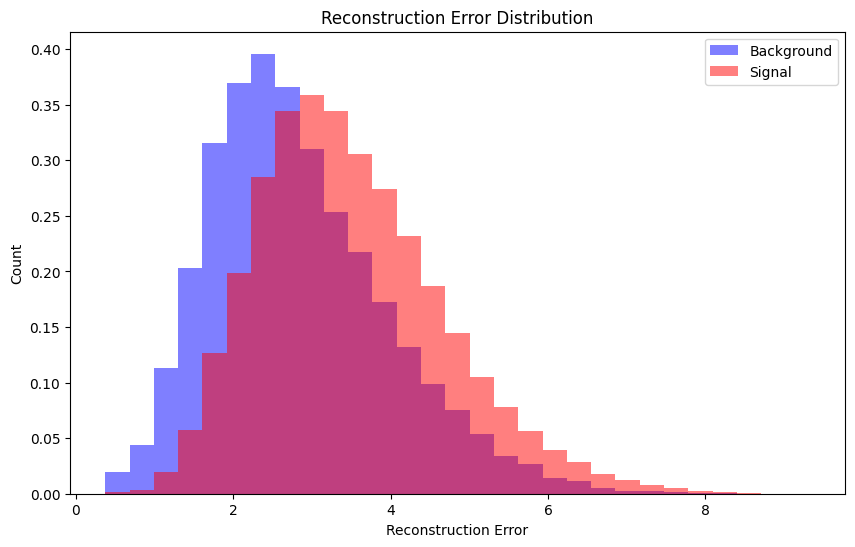

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
bg_ad_score = np.linalg.norm(bg_test_diff, axis=1)
signal_ad_score = np.linalg.norm(signal_diff, axis=1)
bins = np.linspace(
    min(np.min(bg_ad_score), np.min(signal_ad_score)),
    max(np.max(bg_ad_score), np.max(signal_ad_score)),
    30,
)
ax.hist(
    bg_ad_score, bins=bins, alpha=0.5, label="Background", color="blue", density=True
)
ax.hist(
    signal_ad_score, bins=bins, alpha=0.5, label="Signal", color="red", density=True
)
ax.set_xlabel("Reconstruction Error")
ax.set_ylabel("Count")
ax.set_title("Reconstruction Error Distribution")
ax.legend()

In [1]:
fig, ax = plt.subplots(figsize=(10, 6))
bg_ad_score = np.linalg.norm(bg_test_diff, axis=1)
bg_train_ad_score = np.linalg.norm(bg_train_diff, axis=1)
bins = np.linspace(
    min(np.min(bg_ad_score), np.min(bg_train_ad_score)),
    max(np.max(bg_ad_score), np.max(bg_train_ad_score)),
    30,
)
ax.hist(
    bg_ad_score, bins=bins, alpha=0.5, label="Train", color="blue", density=True
)
ax.hist(
    bg_train_ad_score, bins=bins, alpha=0.5, label="Test", color="red", density=True
)
ax.set_xlabel("Reconstruction Error")
ax.set_ylabel("Count")
ax.set_title("Reconstruction Error Distribution")
ax.legend()

NameError: name 'plt' is not defined

In [ ]:
seq_length_sig = (signal_data != -1).all(axis=-1).sum(axis=1)
seq_length_bg = (background_data != -1).all(axis=-1).sum(axis=1)
bg_ad_score = np.linalg.norm(bg_test_diff, axis=1)
signal_ad_score = np.linalg.norm(signal_diff, axis=1)

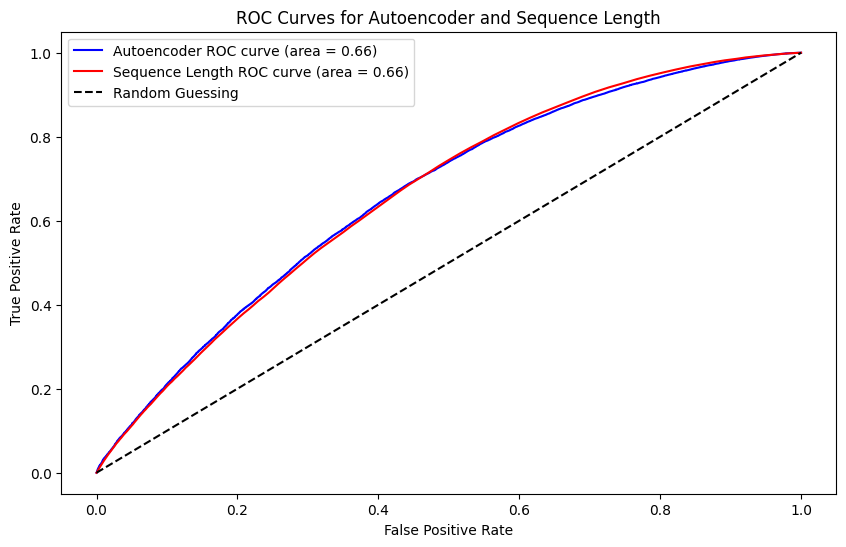

In [ ]:
from sklearn.metrics import roc_curve, auc

ae_fpr, ae_tpr, ae_thresholds = roc_curve(
    np.concatenate([np.zeros(len(bg_test)), np.ones(len(flattened_sig))]),
    np.concatenate([bg_ad_score, signal_ad_score]),
)
ae_roc_auc = auc(ae_fpr, ae_tpr)

seq_length_fpr, seq_length_tpr, seq_length_thresholds = roc_curve(
    np.concatenate([np.zeros(len(seq_length_bg)), np.ones(len(seq_length_sig))]),
    np.concatenate([seq_length_bg, seq_length_sig]),
)
seq_length_roc_auc = auc(seq_length_fpr, seq_length_tpr)
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(
    ae_fpr,
    ae_tpr,
    color="blue",
    label=f"Autoencoder ROC curve (area = {ae_roc_auc:.2f})",
)
ax.plot(
    seq_length_fpr,
    seq_length_tpr,
    color="red",
    label=f"Sequence Length ROC curve (area = {seq_length_roc_auc:.2f})",
)
ax.plot([0, 1], [0, 1], color="black", linestyle="--", label="Random Guessing")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves for Autoencoder and Sequence Length")
ax.legend()
plt.show()

In [ ]:
from sklearn.model_selection import KFold


def test_latent_dim_size(latent_dim, bg_data, signal_data, n_splits=5):
    autoencoder = AutoEncoder(
        input_size=flattened_bg.shape[1],
        latent_dim=latent_dim,
        num_layers=6,
    )

    autoencoder.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-4),
        loss=keras.losses.MeanSquaredError(),
    )
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

    auc_scores = []
    for train_index, test_index in kf.split(bg_data):
        bg_train, bg_test = bg_data[train_index], bg_data[test_index]
        signal_test = signal_data

        autoencoder.fit(bg_train, bg_train, epochs=20, batch_size=512, verbose=0)

        bg_test_diff = bg_test - autoencoder.predict(bg_test)
        signal_diff = signal_test - autoencoder.predict(signal_test)

        bg_ad_score = np.linalg.norm(bg_test_diff, axis=1)
        signal_ad_score = np.linalg.norm(signal_diff, axis=1)

        fpr, tpr, thresholds = roc_curve(
            np.concatenate([np.zeros(len(bg_test)), np.ones(len(signal_test))]),
            np.concatenate([bg_ad_score, signal_ad_score]),
        )

        auc_score = auc(fpr, tpr)
        auc_scores.append(auc_score)

    return np.mean(auc_scores), np.std(auc_scores) / np.sqrt(len(auc_scores))

In [ ]:
test_latent_dim_size(16, flattened_bg, flattened_sig)

625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step  
3121/3121 ━━━━━━━━━━━━━━━━━━━━ 2s 713us/step
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 893us/step
3121/3121 ━━━━━━━━━━━━━━━━━━━━ 2s 704us/step
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 873us/step
3121/3121 ━━━━━━━━━━━━━━━━━━━━ 2s 722us/step
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 844us/step
3121/3121 ━━━━━━━━━━━━━━━━━━━━ 2s 698us/step
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 904us/step
3121/3121 ━━━━━━━━━━━━━━━━━━━━ 2s 740us/step


(np.float64(0.668345955930049), np.float64(0.0012642369201742946))